In [1]:
import numpy as np
import numpy.random as rand
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math

%matplotlib inline

# Engineering and Optimisation: Tacoma Bridge and Travelling Salesman Problem

### Abstract 

This report uncovers two distinct projects - the Traveling Salesman Problem and the Tacoma
bridge collapse. Different computational methods were used to solve these problems, for TSP
the problem is addressed using Monte Carlo and Metropolis methods, and with the aid of
simulated annealing. These methods allowed for a probabilistic approach to determine the
shortest path between 30 capital cities in the US. Through iterative testing to find optimal
parameters, the shortest distance obtained was 2318 miles. The Tacoma Bridge simulation was
modelled using two coupled, second-order differential equations, and provided insight on why
this bridge collapsed. This was due to resonance, which amplified oscillations and eventually
resulting in the bridge's failure. 


### Introduction

Optimisation provides the framework for solving many problems such as structural analysis and route planning. This report demonstrates how modern numerical methods can be utilised to solve complex problems in physics, which have effects in the real world, seen in both the
Tacoma bridge collapse and the Traveling Salesman problem.

For the first problem, the Traveling Salesman, the objective is to determine the shortest possible
path connecting a list of 30 US capitals in a closed loop. Without the methods uncovered in this
report, this problem is very complex as there is an unfathomably large amount of possible
routes - 30 ! to be exact. The time a supercomputer would take to execute this path by path is
multiple orders larger than the age of the universe. This is a famous problem that has been
studied by mathematicians at least since the 1920s[1], and has roots even dating back to 1832,
where a book by the German physicist B. Fr. Voigt contains the first known discussion of this
problem[2]. This report attempts to tackle this problem using simulated annealing, a
probabilistic optimisation method. By iteratively improving upon a certain path, and occasionally
allowing 'uphill' moves which result in temporary worse solutions, this function is able to avoid
getting trapped in local minima and tends towards the global minimum [3]- the shortest
possible path. There are many key components that play a role in bringing the simulated
annealing algorithm to life, such as the cooling schedule, pairwise-exchanges, and the fine-
tuning of parameters like the decay parameter and number of iterations. This is what will be
unpacked in the following code.

The second problem in this report is the Tacoma Bridge collapse, a real engineering failure that
stunned everyone in 1940, due to the limited understanding of aerodynamic forces at the time
[4]. It is now understood that this happened due to a wind force that matched the natural
frequency of the bridge, amplifying the oscillations of the vertical displacement and torsion
angle of the bridge. The two second order differential equations in this project describe the
motion of the bridge. Using numerical methods such as Cromer's method and Taylor's method,
it is possible to plot the behaviour of the bridge under different conditions, to understand what
led the bridge to collapse.

Solving these problems have real world implications, for example discovering the reason behind
the Tacoma collapse could lead to this being prevented in a similar scenario in the future, by
adapting engineering methods. Finding the shortest path possible in the TSP problem could be
incredibly useful in modern times. For example, drones are being used more frequently for tasks
such as delivering packages. Determining the shortest path required to move by the drone
reduces time and energy consumption, and makes it so that fewer resources are used on
fuel/batteries.

This report is structured into two sections: Mini-project 1 (TSP) and Mini-project 2 (Tacoma),
providing a detailed explanation of the functions used for each. Results are plotted on figures,
and are interpreted and analysed afterwards.

## Mini-Project 1 - Traveling Salesman Problem 

In this section, we will slove the Traveling Salesman problem. As previously discussed, the goal of the TSP is to find the optimal path between a list of cities.

We begin by importing the map as an image file, which will be used to visually display the path
between cities.


In [2]:
#importing the US map as an image file
import json
import copy

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

map = mpimg.imread("map.png") 

Next, we load "capitals.json" into a list which we can extract and read - capitals_list:

In [3]:
#List of 30 US state capitals and corresponding coordinates on the map
#open capitals.json in read mode

with open('capitals.json', 'r') as capitals_file:
 capitals = json.load(capitals_file) #contains each capital and its coordinates
capitals_list = list(capitals.items())

#all coordinates turned into tuples
capitals_list = [(c[0], tuple(c[1])) for c in capitals_list]

print("This is the full list of cities: {0}".format(capitals_list))
print("")
print("For example, the first city in the list and its coordinates are: {0}".format(capitals_list[0]))

This is the full list of cities: [('Oklahoma City', (392.8, 356.4)), ('Montgomery', (559.6, 404.8)), ('Saint Paul', (451.6, 186.0)), ('Trenton', (698.8, 239.6)), ('Salt Lake City', (204.0, 243.2)), ('Columbus', (590.8, 263.2)), ('Austin', (389.2, 448.4)), ('Phoenix', (179.6, 371.2)), ('Hartford', (719.6, 205.2)), ('Baton Rouge', (489.6, 442.0)), ('Salem', (80.0, 139.2)), ('Little Rock', (469.2, 367.2)), ('Richmond', (673.2, 293.6)), ('Jackson', (501.6, 409.6)), ('Des Moines', (447.6, 246.0)), ('Lansing', (563.6, 216.4)), ('Denver', (293.6, 274.0)), ('Boise', (159.6, 182.8)), ('Raleigh', (662.0, 328.8)), ('Atlanta', (585.6, 376.8)), ('Madison', (500.8, 217.6)), ('Indianapolis', (548.0, 272.8)), ('Nashville', (546.4, 336.8)), ('Columbia', (632.4, 364.8)), ('Providence', (735.2, 201.2)), ('Boston', (738.4, 190.8)), ('Tallahassee', (594.8, 434.8)), ('Sacramento', (68.4, 254.0)), ('Albany', (702.0, 193.6)), ('Harrisburg', (670.8, 244.0))]

For example, the first city in the list and its coo

Before we can proceed, three important functions need to be defined.

'coord' strips an element of the list returning the coordinates.

'coords' similarly removes the city names from the list and leaves only the coordinates.

To show our path on the US map, the function 'show_path' needs to be defined. This overlays the path onto the map, clearly showing the start point with a yellow marker star.


In [4]:
def coord(path):
 """Strip the city name from each element of the path list and return
 a list of tuples containing only pairs of xy coordinates for the
 cities. For example,
 [("Atlanta", (585.6, 376.8)), ...] -> [(585.6,
376.8), ...]
 """
 _, coord = path
 return coord

def coords(path):
 """Strip the city name from each element of the path list and return
 a list of tuples containing only pairs of xy coordinates for the
 cities. For example,
 [("Atlanta", (585.6, 376.8)), ...] -> [(585.6,
376.8), ...]
 """
 _, coords = zip(*path)
 return coords

def show_path(path_, starting_city, w=35, h=15): #note, not only path is required which must be in the form of a list of (x,y) but also the intial city.
 """Plot a TSP path overlaid on a map of the US States & their capitals."""
 path=coords(path_)
 x, y = list(zip(*path))

 _, (x0, y0) = starting_city

 plt.imshow(map)
 plt.plot(x0, y0, 'y*', markersize=15) # y* = yellow star for starting point
 plt.plot(x + x[:1], y + y[:1]) # include the starting point at the end of path
 plt.axis("off")
 fig = plt.gcf()
 fig.set_size_inches([w, h])

The main algorithm for our code is the simulated annealing algorithm. This is what is going to
enable a highly accurate solution to be found for the problem. The core of this algorithm lies in
deciding whether to accept or reject a new path, by comparing its total distance to the current
one. This is done in accordance with a probability function P.


The idea of the algorithm is to occasionally accept paths with greater distances, preventing the
path to be stuck in a local minima, and allows for a wider exploration of the solution space.

Here, T is 'temperature' which is important in deciding whether to reject or accept the new path.
The temperature schedule is a simple exponential decay, and decides how long we spend
exploring the solution space. When T is large, longer distances are more readily accepted,
however as time passes, the chance of accepting worse paths reduces significantly.

### Defining the Temperature Schedule

The backbone of the simulated annealing algorithm is the temperature schedule, therefore
finding the most efficient and effective temperature schedule is important. A Standard
exponential decay schedule is modeled, as well as quadratic, logarithmic and linear schedules to
try and determine which one fits our algorithm best.


This is the exponential temperature decay:


<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Exponential Decay of Temperature with Time')

Text(0.5, 0, 'Time increment (t)')

Text(0, 0.5, 'Temperature (T)')

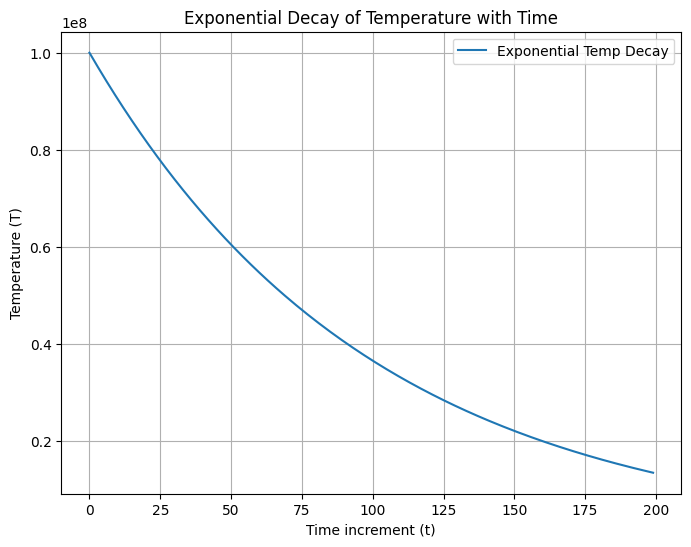

<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Temperature Schedules Comparison')

Text(0.5, 0, 'Time increment (t)')

Text(0, 0.5, 'Temperature (T)')

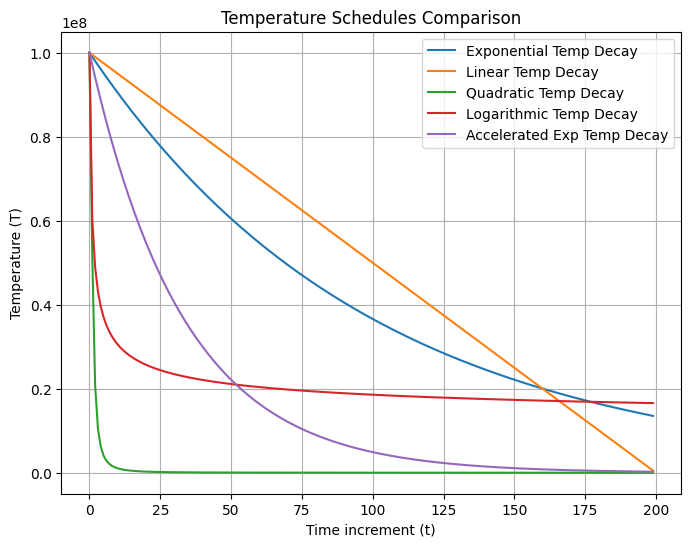

In [5]:
#Define a function to take t and alpha as arguments, returning temperature as the output
def temperature_exponential(t, t_0, alpha):
    return (alpha ** t) * t_0

alpha = 0.99
t_0 = 100000000
N = 200 #The number of iterations - this will be the time increment

exp_temp = []
for t in range(N):
    exp_temp.append(temperature_exponential(t, t_0, alpha))

#Plotting the exponential temperature decay
print("This is the exponential temperature decay:")
plt.figure(figsize=(8,6))
plt.plot(range(N), exp_temp, label="Exponential Temp Decay")
plt.title("Exponential Decay of Temperature with Time")
plt.xlabel("Time increment (t)")
plt.ylabel("Temperature (T)")
plt.grid(True)
plt.legend()
plt.show()

#Experiment by defining other schedule functions - linear, quadratic, logarithmic, and a faster exponential decay
def temperature_linear(t, t_0, k):
    return t_0 - k * t
def temperature_quadratic(t, t_0, q):
    return t_0 * (1 / (1 + q * t ** 2))
def temperature_logarithmic(t, t_0, beta):
    return t_0 * (1 / (1 + beta * np.log(1 + t)))
def accelerated_temperature_exponential(t, t_0, alpha):
    return (alpha ** (a * t)) * t_0
    #a is a constant that accelerates the exponential decay

k = t_0 / 200 #Linear decay constant chosen to result in zero at the end of the iterations
q = 0.95 #Experiment with different values of q and beta
beta = 0.95
a = 3

#Append temperature values for each schedule over N iterations
lin_temp = []
quad_temp = []
log_temp = []
a_exp_temp = []

for t in range(N):
    lin_temp.append(temperature_linear(t, t_0, k))
    quad_temp.append(temperature_quadratic(t, t_0, q))
    log_temp.append(temperature_logarithmic(t, t_0, beta))
    a_exp_temp.append(accelerated_temperature_exponential(t, t_0, alpha))
 
#Plot a single figure to compare each temperature schedule
plt.figure(figsize=(8,6))
plt.plot(range(N), exp_temp, label="Exponential Temp Decay")
plt.plot(range(N), lin_temp, label="Linear Temp Decay")
plt.plot(range(N), quad_temp, label="Quadratic Temp Decay")
plt.plot(range(N), log_temp, label="Logarithmic Temp Decay")
plt.plot(range(N), a_exp_temp, label="Accelerated Exp Temp Decay")
plt.title("Temperature Schedules Comparison")
plt.xlabel("Time increment (t)")
plt.ylabel("Temperature (T)")
plt.grid(True)
plt.legend()
plt.show()

From the plot, logarithmic and quadratic decay schedules are clearly not going to effectively
explore the solution space, as they rapidly decrease in the early time stages. On the other hand,
it can be argued that linear decay spends too long exploring the solution space, and may not
result in the global minimum, and instead may be too far away. Clearly the best option is to
choose an exponential temperature decay. This explores the solution space for a respectable
amount of time, before closing in and accepting better paths.

Interestingly, the accelerated exponential temperature decay can also be achieved by varying the
decay parameter (alpha). Varying alpha for the exponential temperature schedule results in the
following:

<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Comparison of Different Alpha Values on Exponential Temperature Decay')

Text(0.5, 0, 'Time increment (t)')

Text(0, 0.5, 'Temperature (T)')

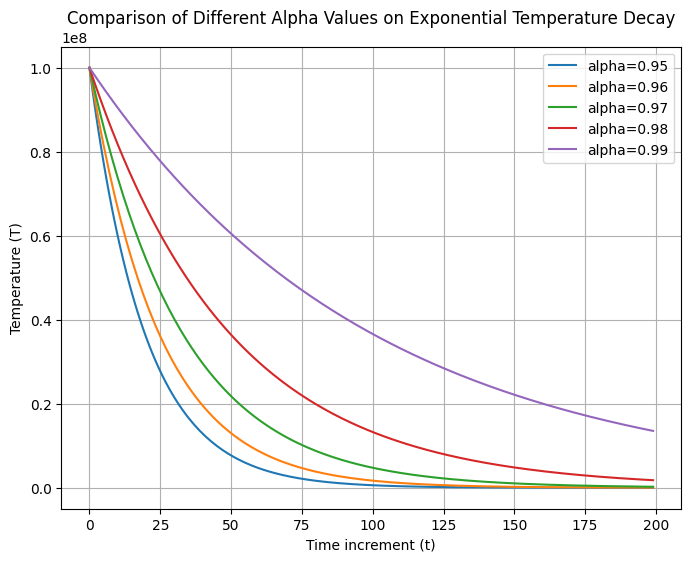

In [6]:
#Vary the decay parameter alpha and record how it affects the temperature function
alpha_vals = np.arange(0.95, 0.99, 0.01) 

#Plot exponential temperature with each value of alpha to allow easy comparison
plt.figure(figsize=(8,6))
for alpha in alpha_vals:
    exp_temp = []
    for t in range(N):
        exp_temp.append(temperature_exponential(t, t_0, alpha))
    plt.plot(range(N), exp_temp, label="alpha={0}".format(alpha))

plt.title("Comparison of Different Alpha Values on Exponential Temperature Decay")
plt.xlabel("Time increment (t)")
plt.ylabel("Temperature (T)")
plt.grid(True)
plt.legend()
plt.show()



Alpha clearly controls the rate of 'cooling' of the temperature schedule, with higher values of
alpha resulting in a slow decay, which explores the solution space for a longer time. An alpha
value between 0.97 and 0.96 would be the most likely to converge quickly and accurately, whilst
still exploring the solution space effectively. However any alpha value below 0.95 risks
converging too rapidly and getting trapped in a local minima.

### Constructing a Random Path

The 'construct_random_path' function is defined to take a random sample of the desired amount of cities, and create a closed path between them.

In [7]:
num_cities = 8 #Intiialise the number of cities in the path

#Define a function to construct a random path of cities
def construct_random_path(capitals_list, num_cities):
    rand_path = random.sample(capitals_list, num_cities) 
    rand_path.append(rand_path[0]) #Creating a closed loop by ensuring start and end city is the same

    return rand_path


#Call the function by generating a random path
rand_path = construct_random_path(capitals_list, num_cities)
print("Here is a random closed path of {0} cities,".format(num_cities), rand_path)

Here is a random closed path of 8 cities, [('Sacramento', (68.4, 254.0)), ('Hartford', (719.6, 205.2)), ('Saint Paul', (451.6, 186.0)), ('Nashville', (546.4, 336.8)), ('Raleigh', (662.0, 328.8)), ('Oklahoma City', (392.8, 356.4)), ('Trenton', (698.8, 239.6)), ('Denver', (293.6, 274.0)), ('Sacramento', (68.4, 254.0))]


### The Pairwise Exchange Function 

The role of this function is to swap two random cities in a path, and return this as a new path.

In [8]:
def pairwise_exchange(rand_path):
    path_new = rand_path.copy() #Copy of the original path is created, which will then be modified
 
    #Two cities are randomly selected from the path for swapping.
    c_1, c_2 = random.sample(range(len(rand_path) - 1), 2)
    #subtracting 1 ensures the last city is unchanged
    #The two cities are swapped in the new path
    path_new[c_1], path_new[c_2] = path_new[c_2], path_new[c_1]

    #Ensure the loop remains closed - as the final city was excluded from the sample we change the last city to match the first 
    path_new[-1] = path_new[0]

    return path_new

#Example random path before and after pairwise exchange
new_rand_path = pairwise_exchange(rand_path)
print("The old path is {0}".format(rand_path))
print()
print("The new path after the pairwise exchange is {0}".format(new_rand_path))


The old path is [('Sacramento', (68.4, 254.0)), ('Hartford', (719.6, 205.2)), ('Saint Paul', (451.6, 186.0)), ('Nashville', (546.4, 336.8)), ('Raleigh', (662.0, 328.8)), ('Oklahoma City', (392.8, 356.4)), ('Trenton', (698.8, 239.6)), ('Denver', (293.6, 274.0)), ('Sacramento', (68.4, 254.0))]

The new path after the pairwise exchange is [('Sacramento', (68.4, 254.0)), ('Hartford', (719.6, 205.2)), ('Nashville', (546.4, 336.8)), ('Saint Paul', (451.6, 186.0)), ('Raleigh', (662.0, 328.8)), ('Oklahoma City', (392.8, 356.4)), ('Trenton', (698.8, 239.6)), ('Denver', (293.6, 274.0)), ('Sacramento', (68.4, 254.0))]


### Calculating Total Path Length

This section builds a function to calculate the total length of a given path. This is achieved using
the standard formula for the distance between two points in 2D, derived from pythagoras'
theorem.


In [9]:
def calc_path_length(new_rand_path):

    #The final city has to be added to the path to ensure closed loop
    closed_path = list(new_rand_path) + [new_rand_path[0]]

    #List of pairs of consecutive cities
    city_pair = zip(closed_path, closed_path[1:])
    total_path_length = 0

    for c_1, c_2 in city_pair:
        #Extracts the x and y coordinates from both cities in the pair
        (x1, y1) = c_1[1]
        (x2, y2) = c_2[1] #The first index [1] represents the coordinates of the tuple
        
        #Use the standard distance formula between two points in 2D
        dist_between_pair = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
        total_path_length += dist_between_pair #add the distance to the total length
    return total_path_length

total_path_distance = calc_path_length(new_rand_path)
print("The total path distance of the route {0} is {1:.7}".format(new_rand_path, total_path_distance))


The total path distance of the route [('Sacramento', (68.4, 254.0)), ('Hartford', (719.6, 205.2)), ('Nashville', (546.4, 336.8)), ('Saint Paul', (451.6, 186.0)), ('Raleigh', (662.0, 328.8)), ('Oklahoma City', (392.8, 356.4)), ('Trenton', (698.8, 239.6)), ('Denver', (293.6, 274.0)), ('Sacramento', (68.4, 254.0))] is 2533.845


### Simulated Annealing - The Equation

The probability function used in the algorithm is given as:

$P = e^{-\frac{(d_{\text{new}} - d_{\text{old}})}{T}}$

If $ d_{\text{new}} < d_{\text{old}} $ then the path is always accepted.

If $ d_{\text{new}} > d_{\text{old}} $ then the path has a probability to be accepted, even though
this would lead to a longer overall distance.

The newly defined temperature T is what governs the probability of accepting a worse path -
higher temperatures have a greater chance for accepting a worse path. As T cools, the algorithm
is much less likely to select a worse solution, concentrating on improving the current best
solutions.


### Simulated Annealing - The Algorithm

This is the key to solving this problem, utilising the previously defined functions to obtain the
best possible distance. In this section, we are going to start with parameters that have been
tuned to output optimal results, and we are going to do 200 attempts (number of swaps). A
higher amount of swaps would most likely lead to a slightly more refined solution, however this
comes at the cost of extra run-time. Efficiency is also key in tackling a problem like this, the point
is to show the usefulness of the algorithm and prevent 'brute-forcing' solutions.

In this first section of code, the simulated_annealing function is initialised and the optimum path
between 8 cities is found.


the optimal path for this random sample of 8 cities is:
('Montgomery', (559.6, 404.8))
('Nashville', (546.4, 336.8))
('Providence', (735.2, 201.2))
('Columbus', (590.8, 263.2))
('Indianapolis', (548.0, 272.8))
('Denver', (293.6, 274.0))
('Salem', (80.0, 139.2))
('Austin', (389.2, 448.4))
('Montgomery', (559.6, 404.8))
Best route distance was found to be 1622.88


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Temperature (log)')

Text(0, 0.5, 'Distance (log)')

Text(0.5, 1.0, 'Distance against Temperature (Log-Log)')

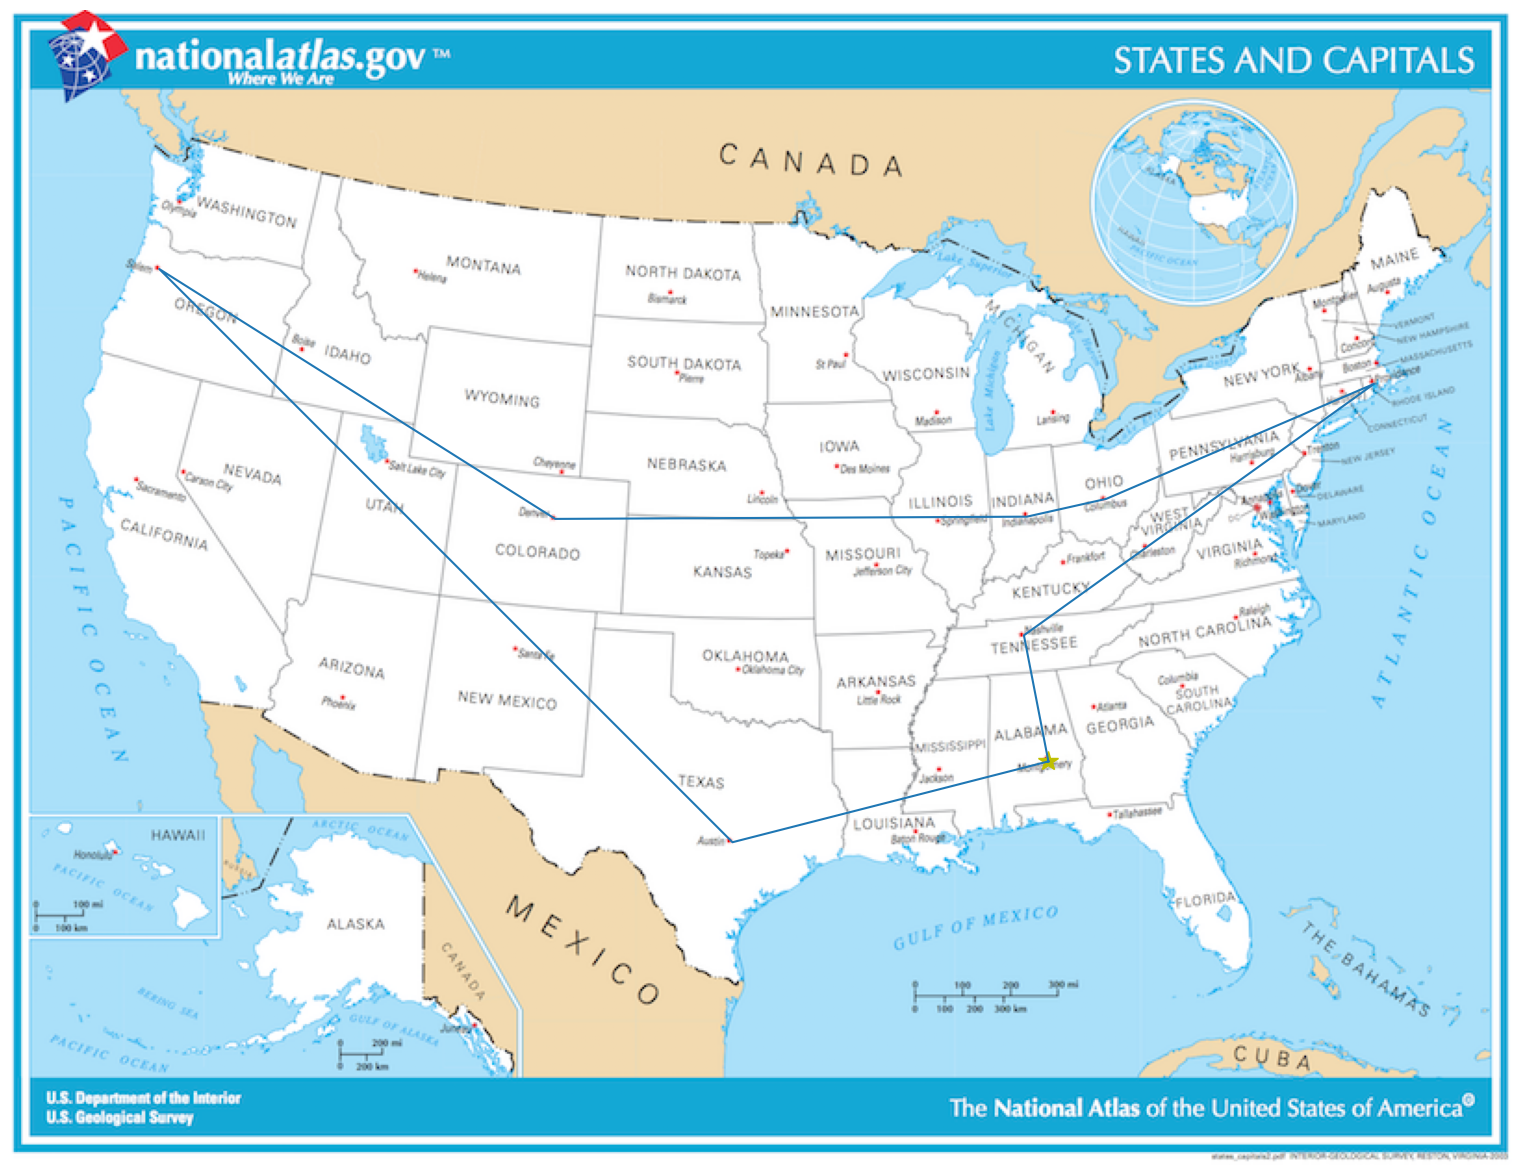

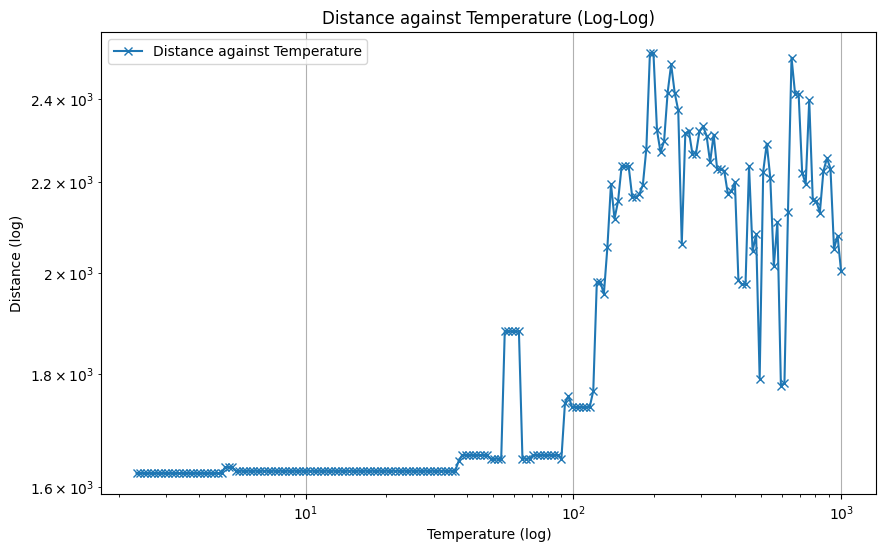

In [10]:
#Initial variables given to calculate path length between 8 cities
N = 200
alpha = 0.97
t_0 = 1000
num_cities = 8

start_path = construct_random_path(capitals_list, num_cities)

#Define the simulated annealing function to find the optimum path
def simulated_annealing(start_path, t_0, alpha, N):

    #Initialize lists for the current and optimal paths, leaves the originals unchanged
    current_path = start_path.copy()
    current_distance = calc_path_length(current_path)

    optimal_path = current_path.copy()
    optimal_distance = current_distance

    dist = [] #Store values of distance and temperature to plot
    temps = []
    temp = t_0 #Intialise temperature as t_0

    for i in range(N):
    
    #Complete a pairwise exchange from our previously defined functions
        pair_exch_path = pairwise_exchange(current_path)
        pair_exch_dist = calc_path_length(pair_exch_path)

        #Calculate whether the new path is shorter than the current path
        if pair_exch_dist - current_distance < 0:
            current_path = pair_exch_path
            current_distance = pair_exch_dist

        #If a random number between 0 and 1 is less than the certain probability, accept this path
        elif rand.uniform(0,1) < math.exp(-(pair_exch_dist - current_distance) / temp):
            current_path = pair_exch_path
            current_distance = pair_exch_dist
        else:
            pass

        #If the current distance is the best path, update the variables
        if current_distance < optimal_distance:
            optimal_path = current_path.copy()
            optimal_distance = current_distance

        #Append this distance and temperature to the lists for plotting
        dist.append(current_distance)
        temps.append(temp)
        temp *= alpha #Update the temperature for the new loop

    return optimal_path, optimal_distance, dist, temps

#Run the simulated annealing algorithm to find the best path
optimal_path, optimal_distance, dis, temps = simulated_annealing(start_path, t_0, alpha, N)

print("the optimal path for this random sample of 8 cities is:")
for city in optimal_path:
    print(city)
    
#Print the optimal distance found
print("Best route distance was found to be {0:.2f}".format(optimal_distance))

#Plotting the optimal path on the map
first_city = optimal_path[0]
show_path(optimal_path, first_city, w=35, h=15)

#Plotting distance vs temperature, as a log-log graph
plt.figure(figsize=(10,6))
plt.plot(temps, dis, marker='x', label="Distance against Temperature")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Temperature (log)")
plt.ylabel("Distance (log)")
plt.title("Distance against Temperature (Log-Log)")
plt.grid(True)
plt.legend()
plt.show()


Looking at the map we can see that the function has almost certainly produced the best path
between these eight random cities. This goes to show for a smaller amount of cities it is very
possible to get the exact shortest distance.

The graph plotted of Distance (log) vs Temperature (log) shows at higher temperatures, there
are fluctuations in distance. Occasionally, the distance increases, showing the role of the
probability function. Overall, there is an obvious downward trend from the start of the graph, as
at lower temperatures the distance practically remains unchanged suggesting that the optimal
route has been found.

One parameter to further explore is the decay paremeter alpha, which determines the
temperature schedule. Now that we have the simulated annealing function working, we can test
different values of alpha and see the lowest distance obtained using these. The following code
plots a graph showing the final distance and the journey it took to obtain it for each value of
alpha.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Temperature (log)')

Text(0, 0.5, 'Distance (log)')

Text(0.5, 1.0, 'Distance vs Temperature for Varying Alpha (Log-Log)')

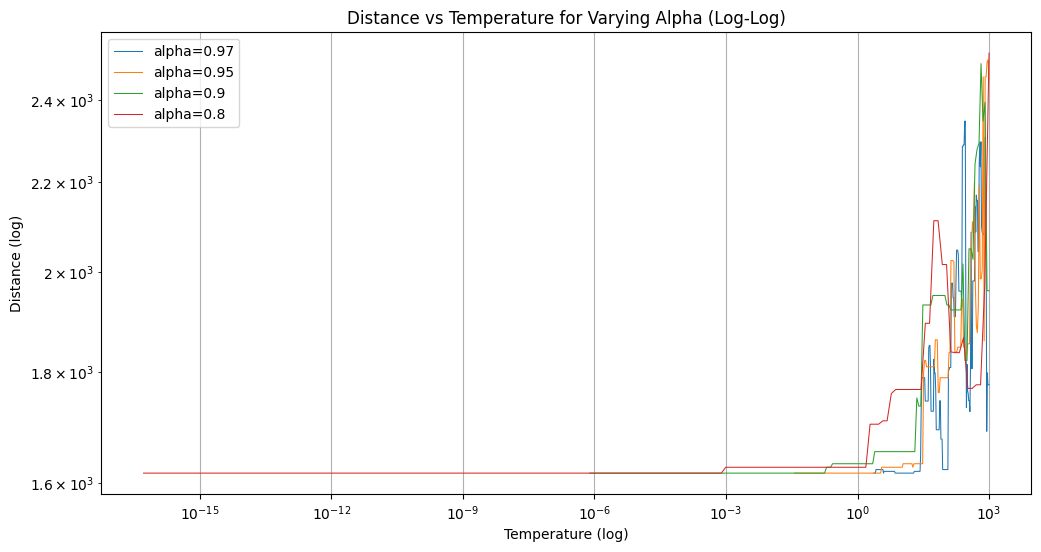

The final optimal distances for different Alpha Values are calculated as:
Alpha = 0.97: Final Distance = 1616.777751
Alpha = 0.95: Final Distance = 1616.777751
Alpha = 0.9: Final Distance = 1616.777751
Alpha = 0.8: Final Distance = 1616.777751


In [11]:
alpha_vals = [0.97, 0.95, 0.9, 0.8]
final_dists = [] #A list of the best distance found for each alpha

plt.figure(figsize=(12,6))

for alpha in alpha_vals:
    temps = []
    dist = []
    temp = t_0
    optimal_path, optimal_distance, dis, temp_list = simulated_annealing(start_path, t_0, alpha, N)
    temps.extend(temp_list) #.extend ensures that dist and temps store the same amount of values
    dist.extend(dis)
    final_dists.append(optimal_distance)

    #plot dist vs temps for each alpha
    plt.plot(temps, dist, label="alpha={0}".format(alpha), linewidth=0.75)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Temperature (log)")
plt.ylabel("Distance (log)")
plt.title("Distance vs Temperature for Varying Alpha (Log-Log)")
plt.grid(True)
plt.legend()
plt.show()

#Print the optimal distances for each alpha value
print("The final optimal distances for different Alpha Values are calculated as:")
for i in range(len(alpha_vals)):
    print("Alpha = {0}: Final Distance = {1:.6f}".format(alpha_vals[i], final_dists[i]))

Here all the different values of alpha used all result in the same, or nearly the same, final
distance. This further suggests that the algorithm is highly accurate, and likely to produce a
perfect path, for a lower number of cities. However the difference lies in the time taken to obtain
the optimal distance. Alpha = 0.8 potentially explores the solution space for too long, taking the
longest time to converge. To save unnecessary computational run-time, it may be a better
option to consider one of the higher alphas, 0.95 or 0.97.

### Optimal Path for 20 Random Cities

This code is simply repeated changing the 'num_cities' to 20.

The optimal path for this random sample of 20 cities is:
('Jackson', (501.6, 409.6))
('Baton Rouge', (489.6, 442.0))
('Tallahassee', (594.8, 434.8))
('Columbia', (632.4, 364.8))
('Harrisburg', (670.8, 244.0))
('Albany', (702.0, 193.6))
('Richmond', (673.2, 293.6))
('Raleigh', (662.0, 328.8))
('Montgomery', (559.6, 404.8))
('Nashville', (546.4, 336.8))
('Saint Paul', (451.6, 186.0))
('Des Moines', (447.6, 246.0))
('Oklahoma City', (392.8, 356.4))
('Austin', (389.2, 448.4))
('Boston', (738.4, 190.8))
('Providence', (735.2, 201.2))
('Salt Lake City', (204.0, 243.2))
('Salem', (80.0, 139.2))
('Sacramento', (68.4, 254.0))
('Denver', (293.6, 274.0))
('Jackson', (501.6, 409.6))

 The best distance was found to be: 2926.1413155847845


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Temperature (log)')

Text(0, 0.5, 'Distance (log)')

Text(0.5, 1.0, 'Distance vs Temperature for 20 Cities (Log-Log)')

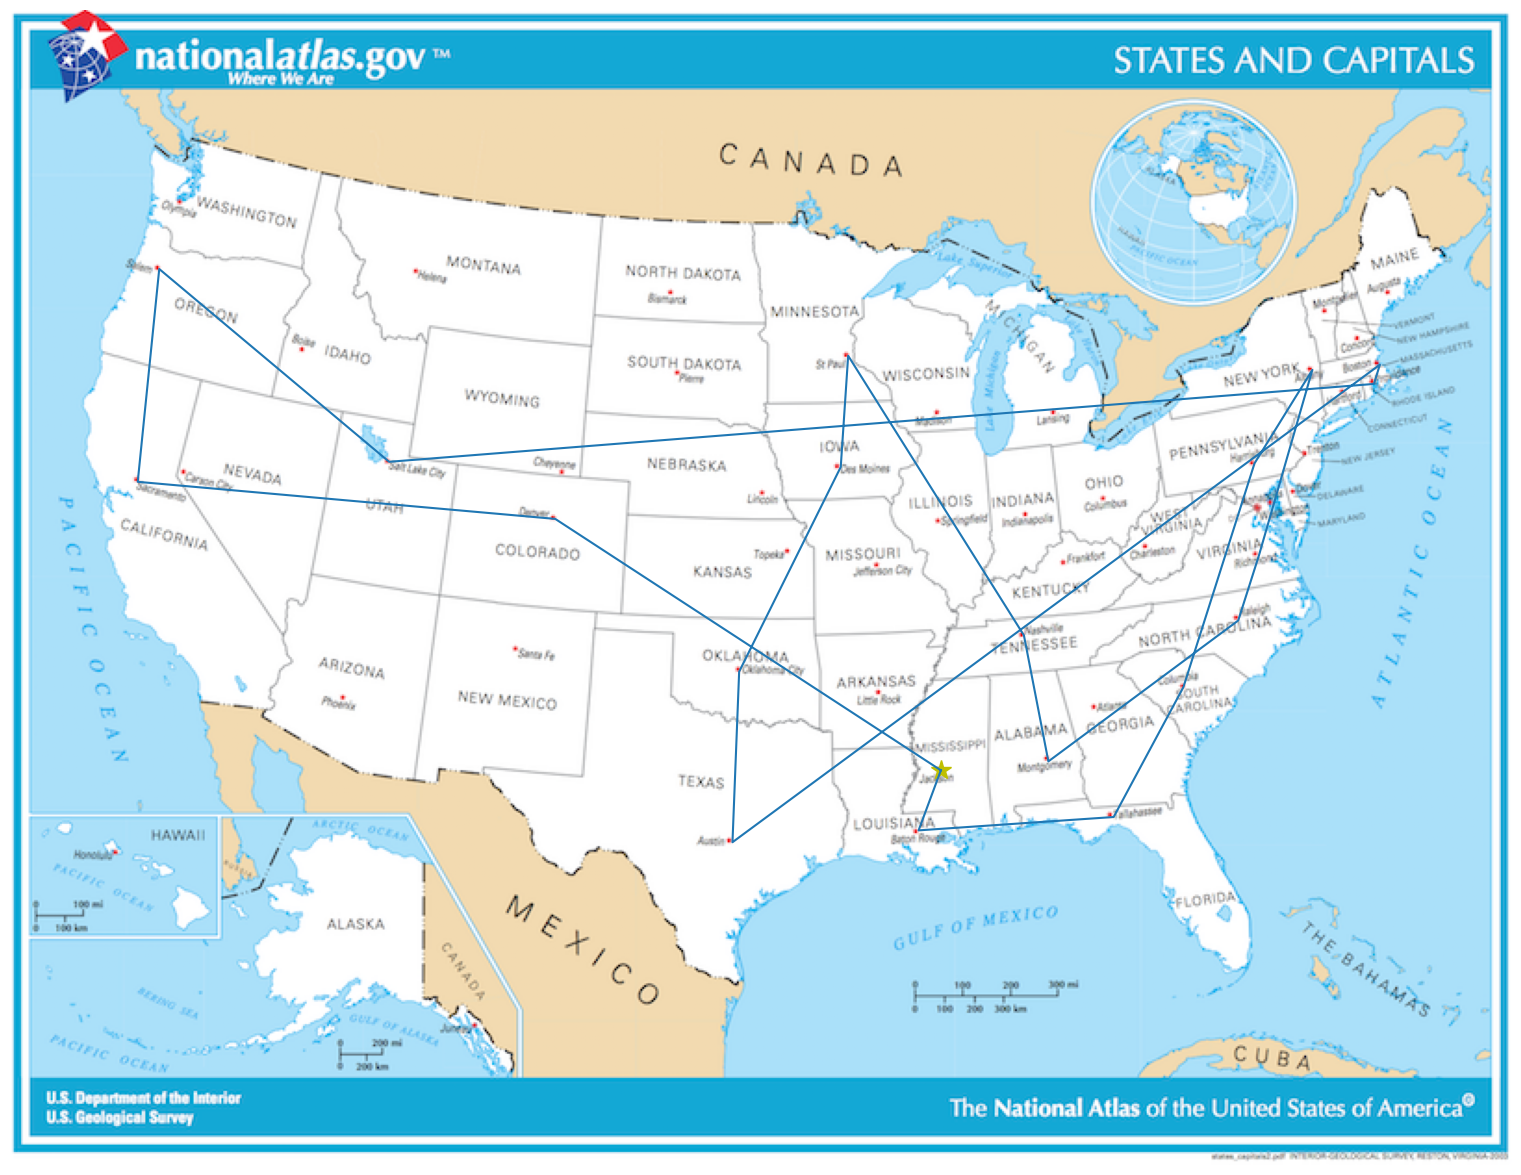

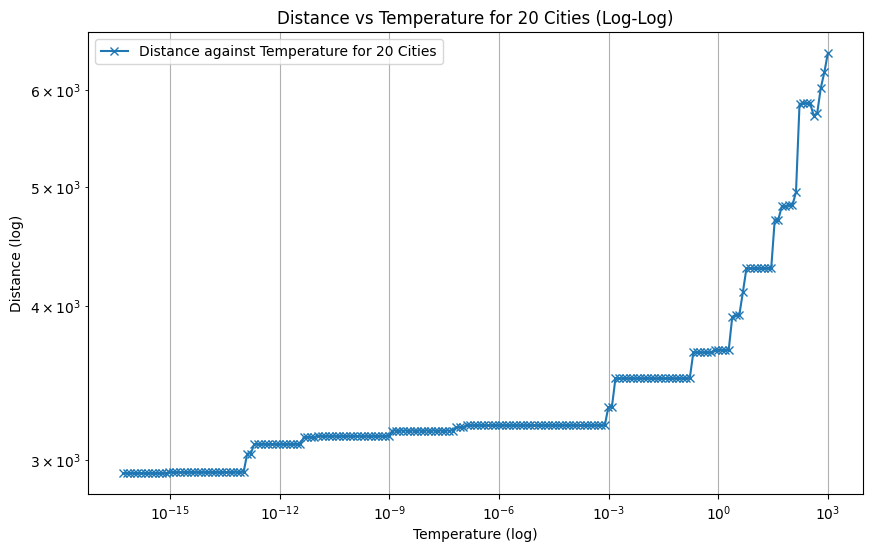

In [12]:
#Repeating the process for 20 cities
num_cities = 20
start_path_20_cities = construct_random_path(capitals_list,
num_cities) #Random path of 20 cities

#Run the simulated annealing for the 20 cities 
optimal_path_20_cities, optimal_distance_20_cities, dis_20_cities, temps_20_cities = simulated_annealing(start_path_20_cities, t_0, alpha, N)

#Print the best path and distance obtained
print("The optimal path for this random sample of 20 cities is:")
for city in optimal_path_20_cities:
    print(city)
print("")

print(" The best distance was found to be: {}".format(optimal_distance_20_cities))

#Show the route on the map
first_city_20 = optimal_path_20_cities[0]
show_path(optimal_path_20_cities, first_city_20, w=35, h=15)

plt.figure(figsize=(10,6))
plt.plot(temps_20_cities, dis_20_cities, marker="x", label="Distance against Temperature for 20 Cities")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Temperature (log)")
plt.ylabel("Distance (log)")
plt.title("Distance vs Temperature for 20 Cities (Log-Log)")
plt.grid(True)
plt.legend()
plt.show()

Analysing the distance vs temperature graph, it is clear to see convergence to an accepted
distance minima. This still yields high accuracy in the final best distance obtained, however it is
worth noticing that with 200 runs only it is unlikely to find the perfect route on the first run. This
could be improved by increasing the amount of runs, and also looping the simulated annealing
function to give a higher chance of the global minimum to be found. Of course, this leads to a
much higher run-time which is something to be considered. Furthermore, from the graph it is
clear to see that the distance does not spend a huge amount of time at the lowest distance,
suggesting if the simulated annealing function was allowed to run for longer a more optimal
route would be eventually found.


### Optimal Distance for all 30 Cities

The algorithm is ready to be taken to the final stage - calculating the shortest path length
between all 30 cities. Increasing the number of cities to this number increases the complexity of
the problem exponentially, leading to the algorithm struggling to consistently locate the global
minimum. However, the results tend to agree with eachother within a relatively small margin of
error.

From our previous example of 20 cities it is clear that 200 iterations is not enough. This will be
investigated further by comparing N_1 = 200 iterations with N_2 = 10000, a much higher
number of iterations that doesn't spare a huge amount more computational run-time. The
simulated annealing algorithm will be run 20 times, and the best overall distance found will be
displayed.

The best distance between all the cities for 20 repeats was 2273.2928682135644


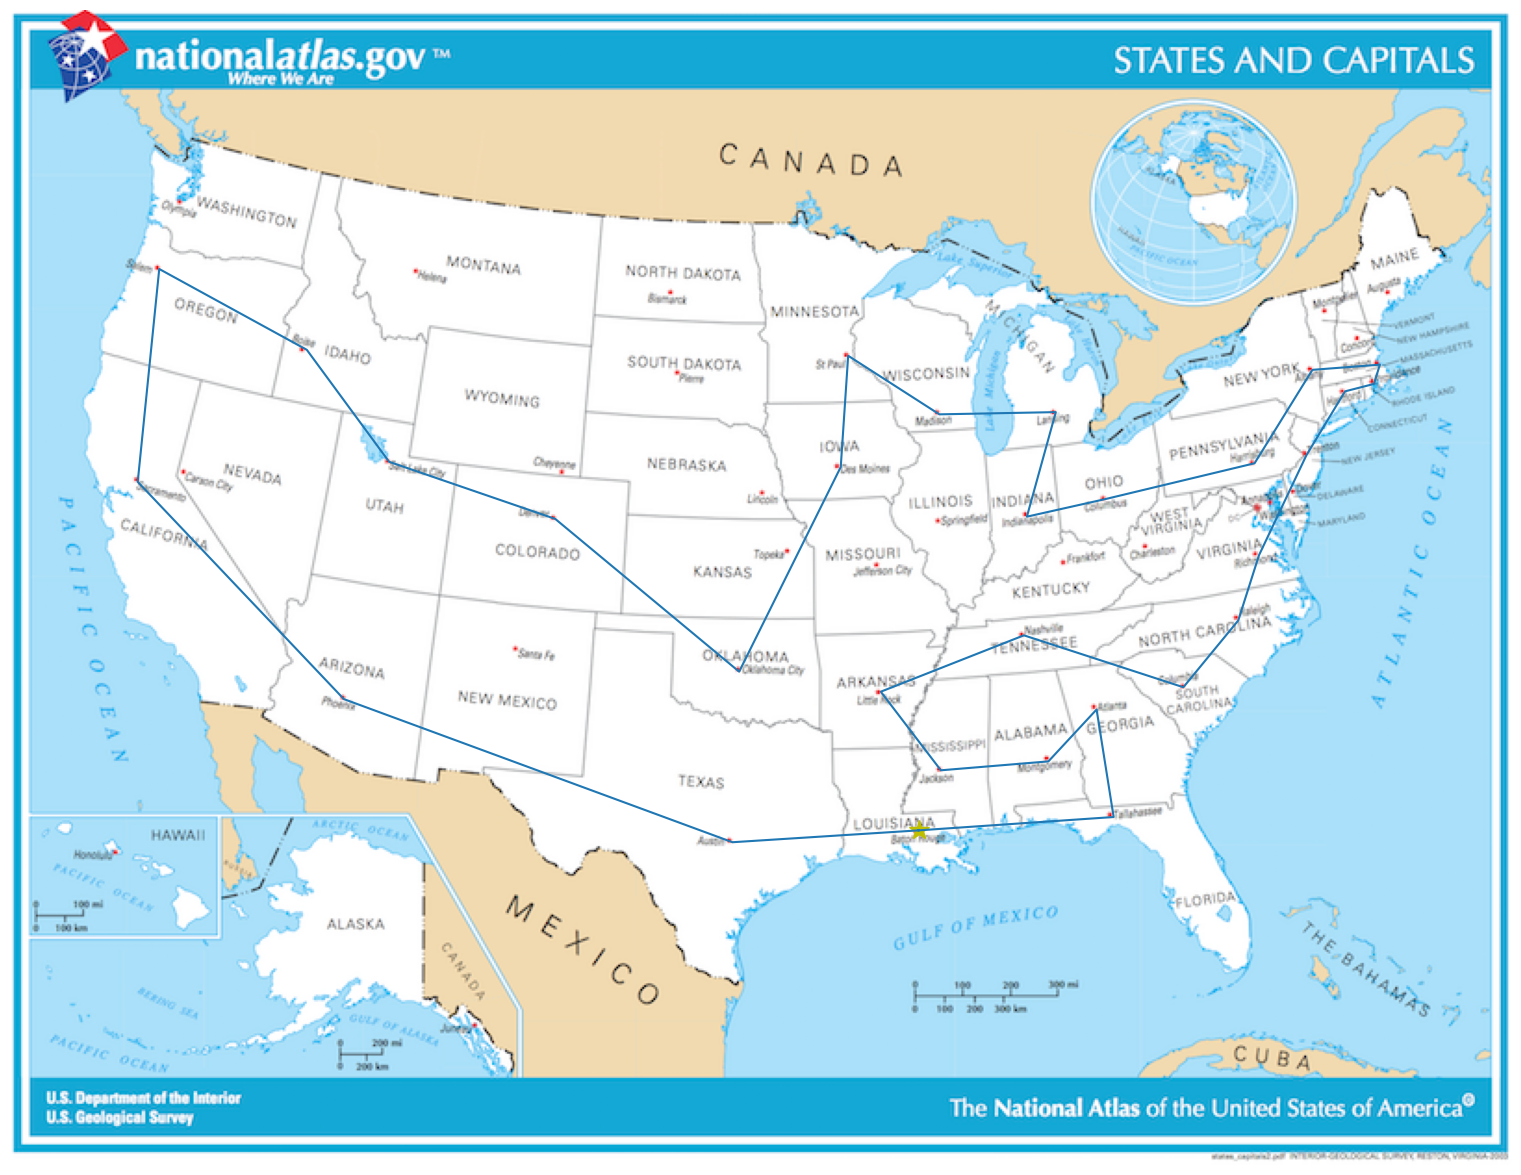

In [13]:
#For all the cities in the list
num_cities = 30
alpha = 0.97 #On average, this value of alpha produces the shortest optimum distance based on previous trials

N_1 = 200
N_2 = 10000 #Investigating the effect of increasing the number of iterations
num_repeats = 20 #Amount of times the simulated annealing function will run

start_path_all_cities = construct_random_path(capitals_list, num_cities)
best_dist = 100000000 #Choose a number high enough that the code will always change the initial best_dist
best_path = [] #Store the best path for each run
distances_1 = []
distances_2 = [] #Stores distances for N_1 and N_2

#Simulated annealing for the first case, N_1 iterations
for repeat in range(num_repeats):
    optimal_path_all_cities, optimal_distance_all_cities, dists_all, temps_all = simulated_annealing(start_path_all_cities, t_0, alpha, N_1)
    distances_1.append(optimal_distance_all_cities)
    if optimal_distance_all_cities < best_dist:
        best_dist = optimal_distance_all_cities
        best_path = optimal_path_all_cities

#Simulated annealing for second case, N_2 iterations
for repeat in range(num_repeats):
    optimal_path_all_cities, optimal_distance_all_cities, dists_all, temps_all = simulated_annealing(start_path_all_cities, t_0, alpha, N_2)
    distances_2.append(optimal_distance_all_cities)
    if optimal_distance_all_cities < best_dist:
        best_dist = optimal_distance_all_cities
        best_path = optimal_path_all_cities

print("The best distance between all the cities for {0} repeats was {1}".format(num_repeats, best_dist))

first_city = best_path[0]
show_path(best_path, first_city, w=35, h=15)
plt.show()


Below lies a plot comparing the distances obtained when running the simulated annealing
algorithm N_1 times vs N_2 times:


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Repeat')

Text(0, 0.5, 'Distance')

Text(0.5, 1.0, 'Distance obtained for each repeat')

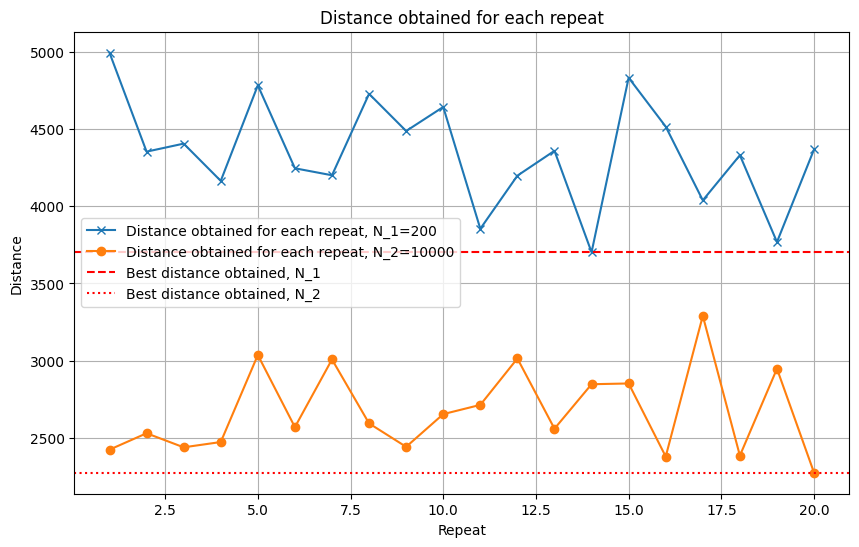

The best distance obtained for N_1=200 was 3701.98, whearas the best distance for N_2=10000 was 2273.29


In [14]:
#Create x-values for the plot, since distances_1 and distances_2 have the same length we can use this for both
x_values = list(range(1, num_repeats + 1))

#Finding the lowest distances for N_1 and N_2 to show on the graph
best_dis_1 = min(distances_1)
best_dis_2 = min(distances_2)

#plot the best distances for each repeat, for N_1 and N_2 on the same graph to compare
plt.figure(figsize=(10, 6))
plt.plot(x_values, distances_1, marker="x", label="Distance obtained for each repeat, N_1=200")
plt.plot(x_values, distances_2, marker="o", label="Distance obtained for each repeat, N_2=10000")

#Add horizontal lines to show the best distance obtained for each N value

plt.axhline(y=best_dis_1, linestyle="--",color = "red", label="Best distance obtained, N_1")
plt.axhline(y=best_dis_2, linestyle=":",color = "red", label="Best distance obtained, N_2")
plt.xlabel("Repeat")
plt.ylabel("Distance")
plt.title("Distance obtained for each repeat")
plt.grid(True)
plt.legend()
plt.show()
#Display the best distance for N_1 and N_2
print("The best distance obtained for N_1=200 was {0:.2f}, whearas the best distance for N_2=10000 was {1:.2f}".format(best_dis_1, best_dis_2))


### Open Questions and Discussion

This investigation demonstrated the strength of simulated annealing, in finding optimal paths
yielding the smallest distances between cities.

One interesting idea is how would our model be modified to find the longest path instead of the
shortest path? The main section of the simulated annealing algorithm that would have to be
changed is how we accept and reject the paths. We currently accept the new path if it is shorter
than the current path, however if we flip the condition in the if statement so that we accept if
pair_exch_dist - current_distance > 0, we will accept longer paths. Similarly, the probability
condition will also need reversing, with the exponential becoming math.exp((pair_exch_dist -
current_distance) / temp)) (reversing the sign of the difference of path lengths). This new
algorithm would converge to find the longest path.

The success of the algorithm hinges on the cooling procedure and temperaure schedule, as
these allow a suitable exploration of the solution space, whilst also converging to provide
acccurate solutions. At high temperatures (which will be at the start of the algorithm), poor
solutions are accepted with higher probability, allowing the values to escape a local minima and
prevent being trapped. As the time reaches the later stage in the algorithm, the temperature has
'cooled' and converges to an accurate solution. The importance of these two functions is why we
emphasised the importance of finding the best initial parameters and defining the best cooling
schedule possible.

Another question is how could the algorithm be modified to avoid crossing the central states, if
certain conditions make this unideal. This could be achieved by adding some sort of 'weight'
function to the paths chosen. Another probabilistic approach could be implemented to make
certain paths between cities less likely to be accepted.

Simulated annealing also can be seen in other fields, such as in bioinformatics, where simulated
annealing helps model the huge amount of possibilities that a protein can fold into. This helps to
understand protein interactions and models, which is an essential field of research[5].



## Mini-Project 2 - Tacoma Bridge Collapse



As mentioned previously, this section simulates the tacoma bridge using two coupled, second
order differential equations. Parameters will be varied to try and find the reason of collapse. We
start by defining some of the parameters used:

In [15]:
#Simulation lasts for 100 seconds
t_start=0
t_end=100

#Initial Parameters
d=0.01 #Friction coefficient (s^-1)
a=1 #Force parameter (m^-1)
M=2500 #Mass (kg)
K=10000 #Spring constant (Nm^-1)
l=6 #Road width (m)
dt = 0.01 #Time-step

These values were specifically chosen to represent a section of the bridge before collapse.

The next step is to define the tacoma function, which uses these parameters, inserts them into
the differential equations and models the bridge. It is able to model the bridge using two
methods, Taylor's method and Cromer's method, seen below:


In [16]:
#Define a function to simulate the bridge, taking the initial parameters as arguments
def tacoma(dt=0.01, cromer=False, t_start=0, t_end=100, y_0=0.1, 
           z_0=0, theta_0=0.1, gamma_0=0, d=0.01, l=6, K=10000, M=2500, a=1):
    
    times=np.arange(t_start, t_end+dt, dt) # Create the array of model times
    Nt=len(times) # Number of time-steps

    #Initialise arrays full of zeroes to store values at each timestep
    y=np.zeros(Nt)
    z=np.zeros(Nt)
    theta=np.zeros(Nt)
    gamma=np.zeros(Nt)
    
    # Set the initial conditions
    y[0] = y_0
    z[0] = z_0
    theta[0] = theta_0
    gamma[0] = gamma_0

    #Loop over all of the times, calculating the second derivative of the vertical velocity z_prime
    #And the second derivative of angular velocity gamma_primme at each time-step
    for i in range(Nt-1):
        z_prime = -d * z[i] - (K / M * a) * (np.exp(a * (y[i] - l * np.sin(theta[i]))) + 
                                             (np.exp(a * (y[i] + l * np.sin(theta[i]))) -2))

        gamma_prime = -d * gamma[i] + (3 * np.cos(theta[i]) / l) * (K / M * a) * ((np.exp(a * (y[i] - l * np.sin(theta[i]))) - 
                                                                                   np.exp(a * (y[i] + l * np.sin(theta[i])))))


        #Update z and gamma using the calculated value of their derivatives
        #This results in the value of z and gamma at the next time interval dt
        z[i + 1] = dt * z_prime + z[i]
        gamma[i + 1] = dt * gamma_prime + gamma[i]

        #Two options - Cromer Method and Taylor Method
        #Only difference is using updated gamma and z values in Cromer
        if cromer:
            y[i + 1] = dt * z[i + 1] + y[i]
            theta[i + 1] = dt * gamma[i + 1] + theta[i]

        #Taylor's method - previous values of z and gamma are used
        else:
            y[i + 1] = dt * z[i] + y[i]
            theta[i + 1] = dt * gamma[i] + theta[i]

    return times, theta, y


### Solving the Differential Equation (No External Wind Force)

Running the tacoma function above for the set of defined parameters yields the following
results. Two plots are going to be created for each value of initial torsion angle, 0.01 , 0.1 and 0.0,
one representing a time-series of the torsion angle θ and one representing a time-series of
vertical displacement y.

We are going to repeat this for both methods - the Taylor method and Cromer method.

Starting with the Taylor method:


Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Taylor Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Taylor Method')

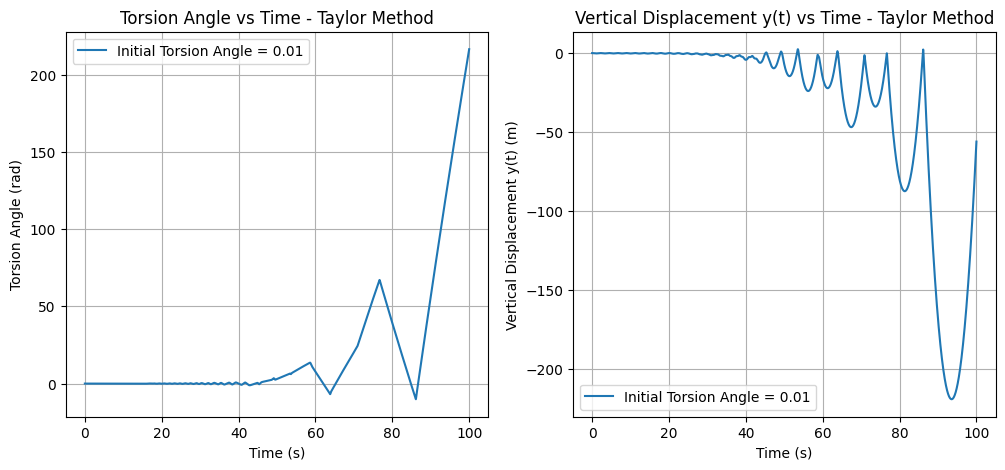

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Taylor Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Taylor Method')

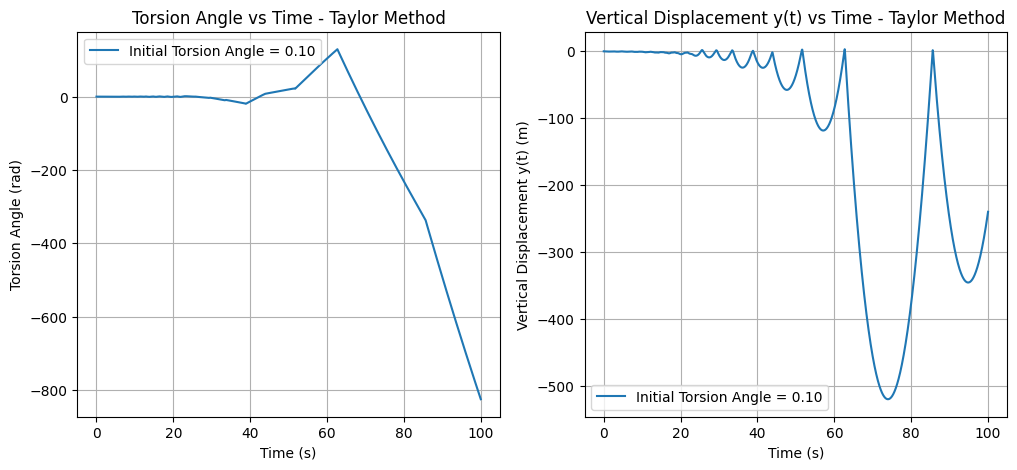

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Taylor Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Taylor Method')

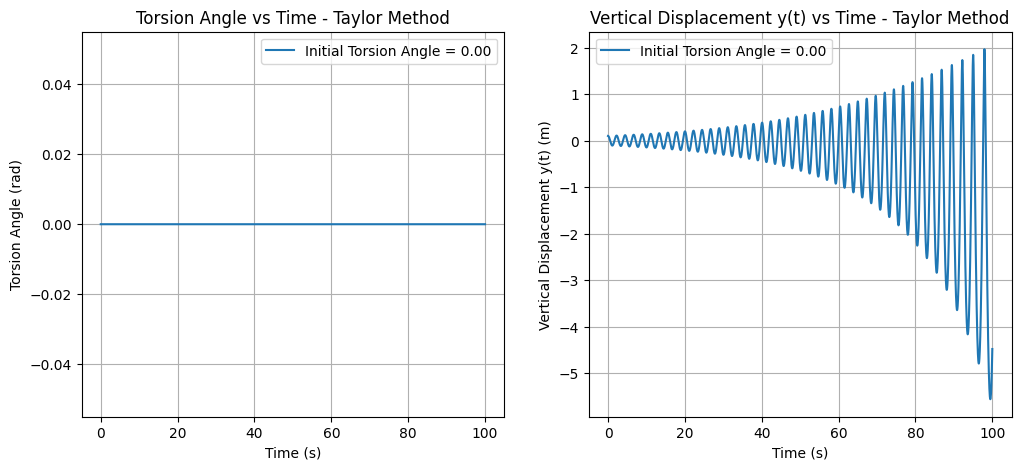

In [17]:
initial_angles = [0.01, 0.1, 0.0] #Initial torsion angles
taylor_results = [] #Empty list to store results of each angle from Taylor's method

#Run the tacoma function for each angle in initial_angles
for angle in initial_angles:
    times, theta, y = tacoma(dt=0.01, cromer=False,t_start=0, t_end=100, 
                             y_0=0.1, z_0=0, theta_0=angle, gamma_0=0, d=0.01, l=6, K=10000, M=2500, a=1)

    taylor_results.append((angle, times, theta, y)) #Append the results into the list for each angle

#Create plots for each initial angle, time-series for both torsion angle and vertical displacement
for angle, times, theta, y in taylor_results:
    fig, subplots = plt.subplots(1,2, figsize=(12,5)) #Creates subpolots, 1 row 2 columns for each angle

    #Graph torsion angle against time on first subplot
    subplots[0].plot(times, theta, label="Initial Torsion Angle = {0:.2f}".format(angle))
    subplots[0].set_xlabel("Time (s)")
    subplots[0].set_ylabel("Torsion Angle (rad)")
    subplots[0].set_title("Torsion Angle vs Time - Taylor Method")
    subplots[0].grid(True)
    subplots[0].legend()
    #Graph vertical displacement against time on second subplot
    subplots[1].plot(times, y, label="Initial Torsion Angle = {0:.2f}".format(angle))

    subplots[1].set_xlabel("Time (s)")
    subplots[1].set_ylabel("Vertical Displacement y(t) (m)")
    subplots[1].set_title("Vertical Displacement y(t) vs Time - Taylor Method")
    subplots[1].grid(True)
    subplots[1].legend()
    plt.show()

Now implementing cromer=TRUE into the tacoma function, we can now display the test using
the Cromer method:

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Cromer Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Cromer Method')

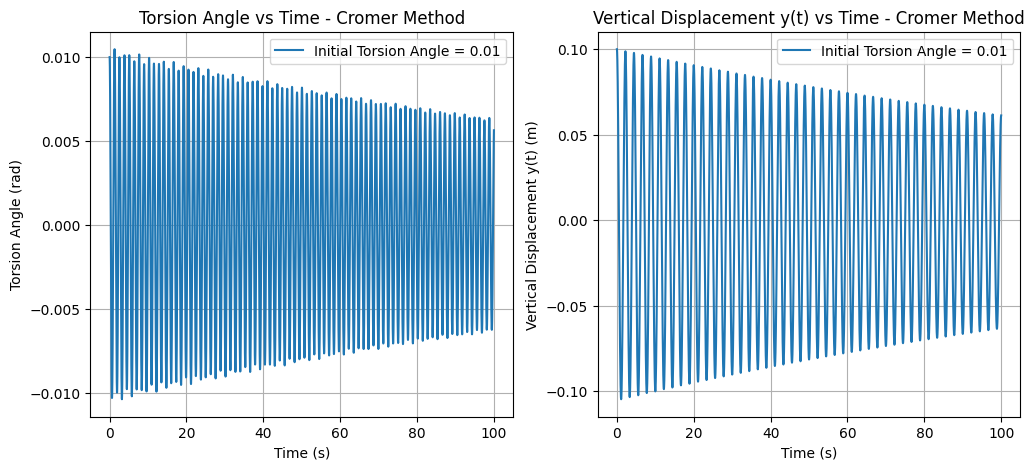

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Cromer Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Cromer Method')

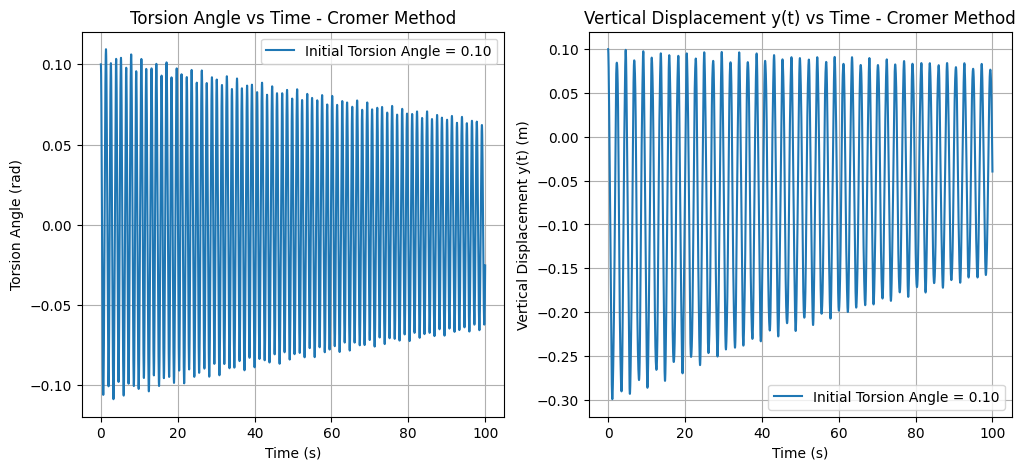

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time - Cromer Method')

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time - Cromer Method')

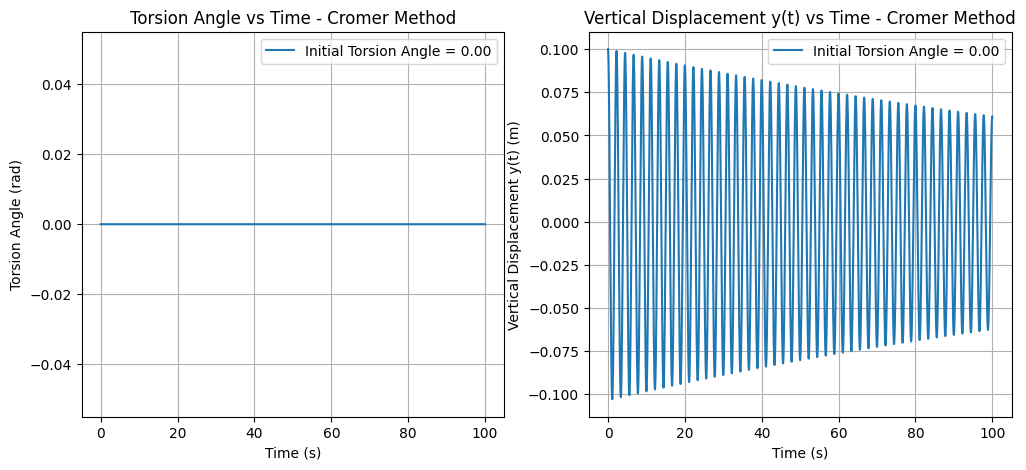

In [24]:
cromer_results = []

#Run the tacoma function for each initial angle using the Cromer method
for angle in initial_angles:
    #Set Cromer = True
    times, theta, y = tacoma(dt=0.01, cromer=True, t_start=0, t_end=100, y_0=0.1, z_0=0,
    theta_0=angle, gamma_0=0, d=0.01, l=6, K=10000, M=2500, a=1)

    cromer_results.append((angle, times, theta, y))

#Create plots for each initial angle, time-series for torsion angle and vertical displacement
for angle, times, theta, y in cromer_results:
    fig, subplots = plt.subplots(1, 2, figsize=(12,5))
    #Create the first subplot for torsion angle against time
    subplots[0].plot(times, theta, label="Initial Torsion Angle = {0:.2f}".format(angle))
    subplots[0].set_xlabel("Time (s)")
    subplots[0].set_ylabel("Torsion Angle (rad)")
    subplots[0].set_title("Torsion Angle vs Time - Cromer Method")
    subplots[0].grid(True)
    subplots[0].legend()

    #Second subplot for vertical displacement against time
    subplots[1].plot(times, y, label="Initial Torsion Angle = {0:.2f}".format(angle))

    subplots[1].set_xlabel("Time (s)")
    subplots[1].set_ylabel("Vertical Displacement y(t) (m)")
    subplots[1].set_title("Vertical Displacement y(t) vs Time - Cromer Method")
    subplots[1].grid(True)
    subplots[1].legend()
    plt.show();


From these graphs, there are a few key differences that can be spotted between the Cromer
method and Taylor's method. Taylor's method seeimingly breaks down and fails to display
oscillatory motion unless the initial torsion angle is 0. Clearly it struggles with outputting an
accurate model when the torsion angle is non-zero.

On the other hand, the Cromer method has a much higher accuracy, reflecting the real motion of
the bridge's oscillations, and also has far greater stability. For this reason, it is the choice for
simulating layered dynamics such as the oscillating bridge. Therefore going forward, Cromer's
method is going to be used to simulate the bridge with wind force.

### Tacoma Simulation under Wind Force

The tacoma function is now going to be modified to account for the wind force, which is
modelled with the equation: $ A \sin(\omega t) $. A here represents the acceleration amplitude,
and ω represents the force's period.

This will lead to a function that accurately demonstrates the behaviour of the bridge under
different wind conditions:

In [19]:
#Define a function to calculate z_prime with wind acceleration
#Values for calculating z_prime and gamma_prime are specified in tacoma_wind - not necessary here

def calculate_z_prime_wind(d, z, K, M, y, theta, wind_accel, a, l):
    return -d * z - (K / (M * a)) * (np.exp(a * (y - l * np.sin(theta))) + 
                                     (np.exp(a * (y + l * np.sin(theta))) - 2)) + wind_accel

#Define a function to calculate gamma_prime, using the previous gamma_prime equation
def calculate_gamma_prime(d, gamma, theta, l, K, M, a, y):
    return -d * gamma + (3 * np.cos(theta) / l) * (K / (M * a)) *((np.exp(a * (y - l * np.sin(theta))) - 
                                                                   np.exp(a * (y + l * np.sin(theta)))))

#Define the final tacoma model that incorporates the wind
def tacoma_wind(dt=0.01, cromer=False, t_start=0, t_end=100, y_0=0.1, z_0=0, theta_0=0.1, gamma_0=0, 
                d=0.01, l=6, K=10000, M=2500, a=1, wind_amp=1, omega=3):
 
    #Array of times and length of times
    times = np.arange(t_start, t_end + dt, dt)
    Nt = len(times)

    #Initialise array of zeros for each variable
    y = np.zeros(Nt)
    z = np.zeros(Nt)
    theta = np.zeros(Nt)
    gamma = np.zeros(Nt)

    #Initial values
    y[0] = y_0
    z[0] = z_0
    theta[0] = theta_0
    gamma[0] = gamma_0

    for i in range(Nt - 1):
        #This is the equation used to calculate wind_accel at each time
        wind_accel = wind_amp * np.sin(omega * times[i])
        #Call the previously defined functions to calculate the derivatives at each time
        z_prime_wind = calculate_z_prime_wind(d, z[i], K, M, y[i], theta[i], wind_accel, a, l)
        gamma_prime = calculate_gamma_prime(d, gamma[i], theta[i], l, K, M, a, y[i])

        #Update z and gamma using the values of their derivatives at each time step
        z[i + 1] = dt * z_prime_wind +z[i]
        gamma[i + 1] = dt * gamma_prime + gamma[i]

        #Cromer or Taylor method
        if cromer:
            y[i + 1] = dt * z[i + 1] + y[i]
            theta[i + 1] = dt * gamma[i + 1] + theta[i]
        else:
            #The Taylor's method is included here as an option, however isn't used due to inaccuracies explored earlier
            y[i + 1] = dt * z[i] + y[i]
            theta[i + 1] = dt * gamma[i] + theta[i]

    return times, theta, y

We will test this new tacoma_wind function, with two wind amplitudes, A=1 ,2 for ω=3, and
record observations.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time, Wind amplitude (A) = 1')

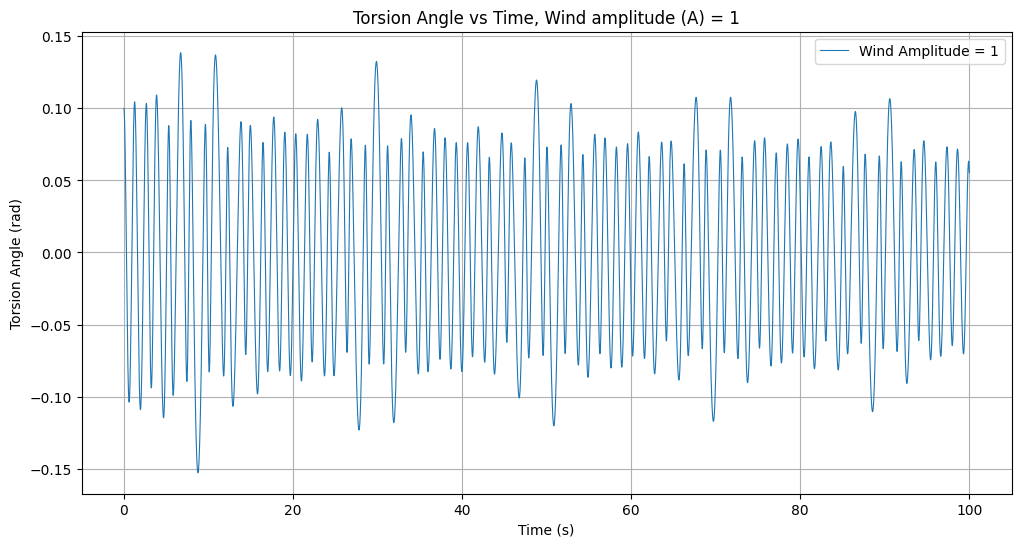

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement (y(t)) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time, Wind amplitude (A) = 1')

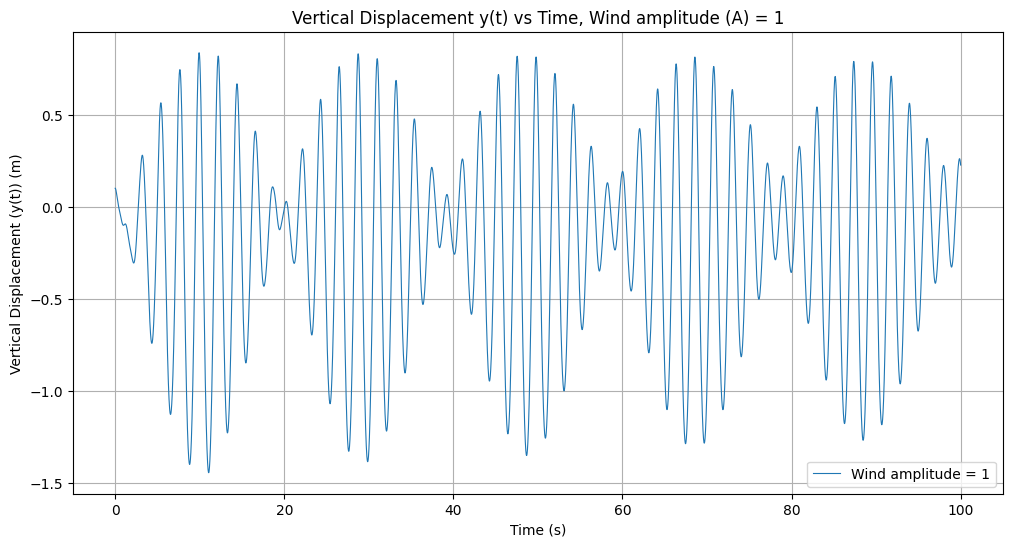

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time, Wind amplitude (A) = 2')

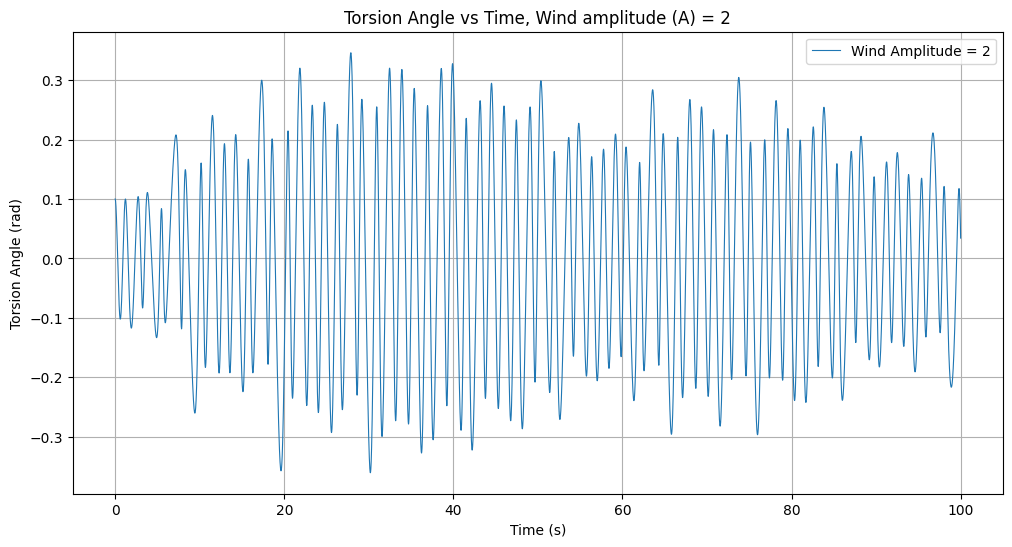

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Vertical Displacement (y(t)) (m)')

Text(0.5, 1.0, 'Vertical Displacement y(t) vs Time, Wind amplitude (A) = 2')

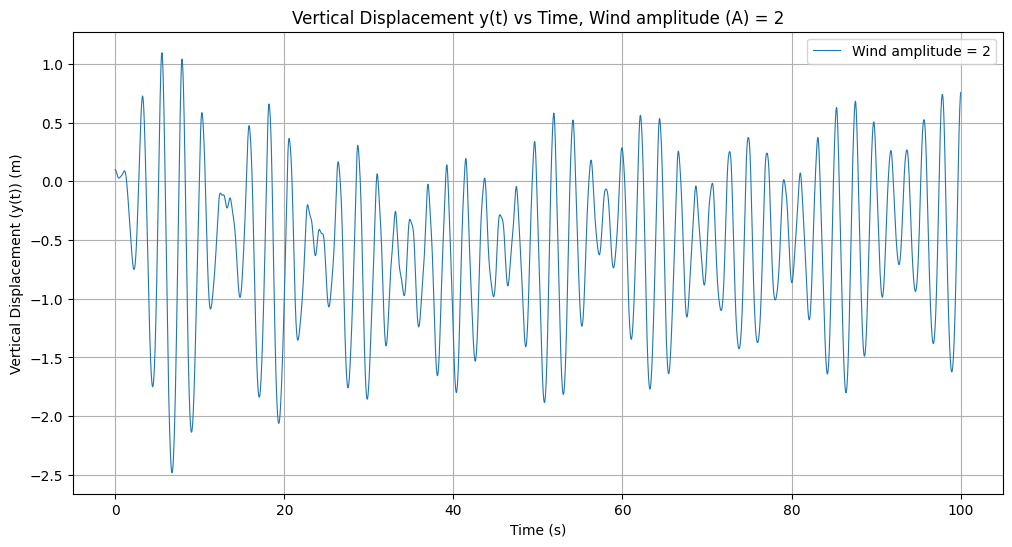

In [20]:
wind_amps = [1,2] #Want to compare these two wind amplitudes
wind_force_results = []

for wind_amp in wind_amps:
    #Use Cromer method
    times, theta, y = tacoma_wind(dt=0.01, cromer=True, t_start=0, t_end=100, y_0=0.1, 
                                  z_0=0, theta_0=0.1, gamma_0=0, d=0.01, l=6, K=10000, M=2500, a=1,
                                    wind_amp=wind_amp, omega=3)
    
    wind_force_results.append((wind_amp, times, theta, y))

#Plot torsion angle and vertical displacement against time for each wind amplitude
for wind_amp, times, theta, y in wind_force_results:
    plt.figure(figsize=(12,6))
    plt.plot(times, theta, label="Wind Amplitude = {0}".format(wind_amp), linewidth=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Torsion Angle (rad)")
    plt.title("Torsion Angle vs Time, Wind amplitude (A) = {0}".format(wind_amp))
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(times, y, label="Wind amplitude = {0}".format(wind_amp), linewidth=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Vertical Displacement (y(t)) (m)")
    plt.title("Vertical Displacement y(t) vs Time, Wind amplitude (A) = {0}".format(wind_amp))
    plt.grid(True)
    plt.legend()
    plt.show()


From these plots, we see small vertical displacement changes for a wind amplitude of 1, and
much larger oscillations for a wind amplitude of 2. This suggests that the natural frequency of
the bridge is around the ω=2 mark. The torsion angle ($\theta $) is also varying a lot more for
ω=2, suggesting larger oscillations around this point.

Focusing on wind_amp = 2, as this is where the more indicitave data for resonance lies, the goal
of this next block of code is to test the calculation for a range of closely placed wind force
frequencies, so we can targer where the natural frequency is likely to be.


<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Torsion Angle (rad)')

Text(0.5, 1.0, 'Torsion Angle vs Time for Varying Wind Frequencies (ω)')

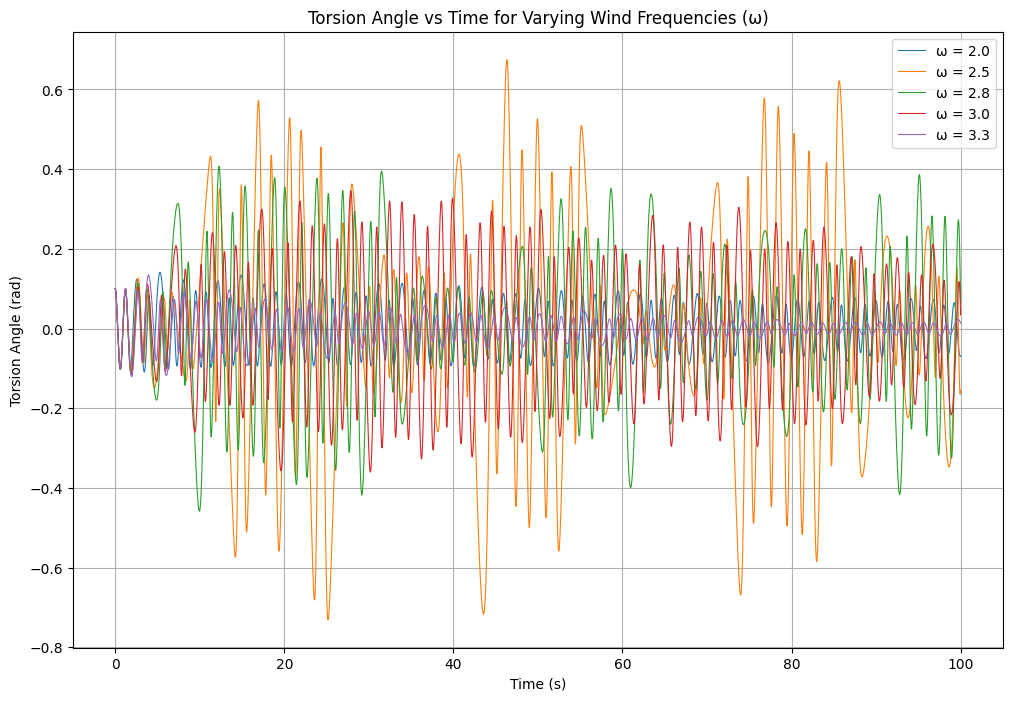

<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Time (s) ')

Text(0, 0.5, 'Vertical Displacement y(t) (m)')

Text(0.5, 1.0, 'Vertical Displacement vs Time for Varying Wind Frequencies (ω) ')

<function matplotlib.pyplot.show(close=None, block=None)>

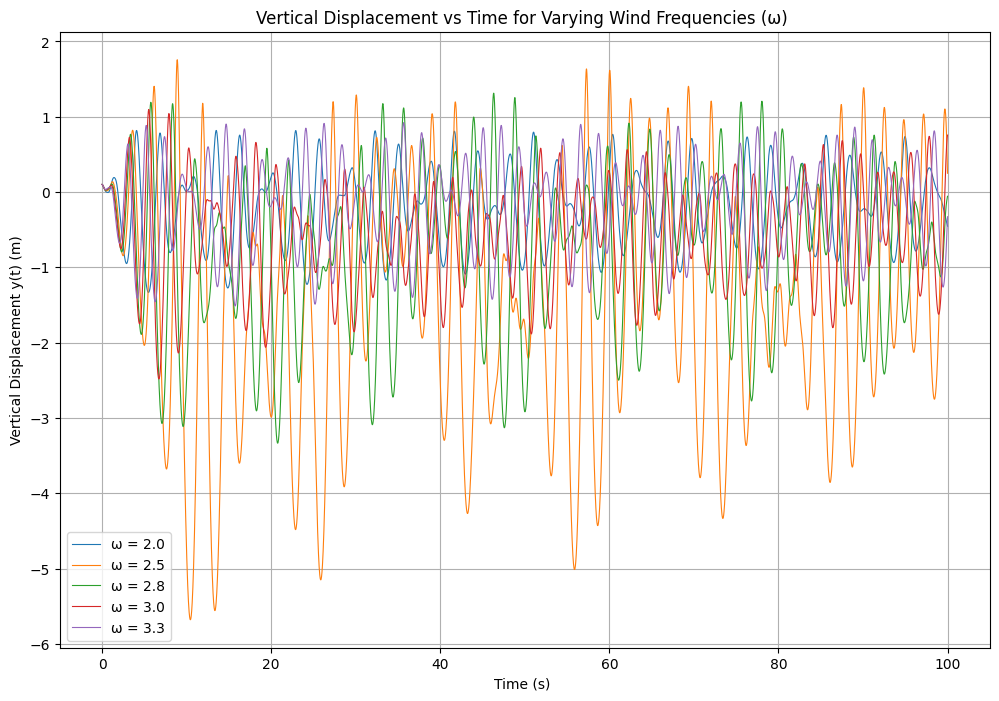

In [21]:
omega_wind_frequencies = [2.0, 2.5, 2.8, 3.0, 3.3] #List of wind frequencies to compare
wind_amp = 2 #Keep the acceleration amplitude constant
varied_freq_results = []

for freq in omega_wind_frequencies:
    times, theta, y = tacoma_wind(dt=0.01, cromer=True, t_start=0, t_end=100, 
                                  y_0=0.1, z_0=0, theta_0=0.1, gamma_0=0, d=0.01, 
                                  l=6, K=10000, M=2500, a=1, wind_amp=2, omega=freq)
    varied_freq_results.append((freq, times, theta, y))

#Plot Torsion angle against time for all frequencies
plt.figure(figsize=(12,8))
for freq, times, theta, y in varied_freq_results:
    plt.plot(times, theta, label="ω = {0}".format(freq), linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Torsion Angle (rad)")
plt.title("Torsion Angle vs Time for Varying Wind Frequencies (ω)")
plt.grid(True)
plt.legend()
plt.show()

#Plot Vertical displacement against time for all frequencies
plt.figure(figsize=(12,8))
for freq, times, theta, y in varied_freq_results:
    plt.plot(times, y, label="ω = {0}".format(freq), linewidth=0.8)
plt.xlabel("Time (s) ")
plt.ylabel("Vertical Displacement y(t) (m)")
plt.title("Vertical Displacement vs Time for Varying Wind Frequencies (ω) ")
plt.grid(True)
plt.legend()
plt.show

The two plots above highlight the significance of varying wind frequencies when A is kept
constant. Clearly, ω has a huge impact on the vertical displacement and torsion angle
amplitudes. The graphs show the highest, most chaotic oscillations for when ω=2.5, suggesting
around this frequency is when the wind force has the greatest effect on the bridge. Oscillatory
motion of the vertical displacement and torsion angle is expected here, as it describes how the
bridge is oscillating out of control in real time.

Next, a heatmap has been constructed to graphically display the dependence of torsion angle on
both time and wind frequency (ω). The color code on the right-hand side corresponds to the
torsion angle at each time.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Omega (ω)')

Text(0.5, 1.0, 'Heat map of Torsion angle vs Time and Omega (ω)')

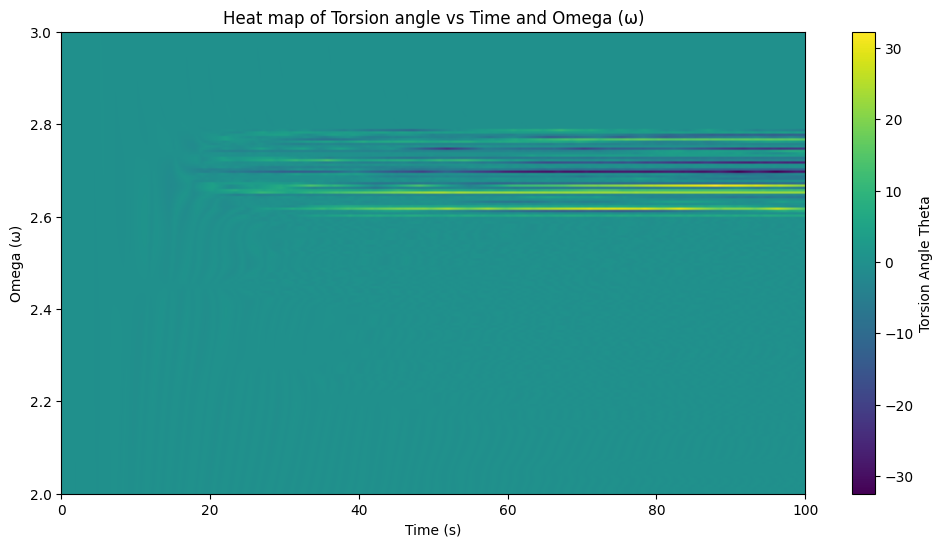

In [22]:
#Define a function that will generate a heatmap showing the torsion angle against time, across
#the range of omega frequencies.
def tacoma_heatmap(dt=0.01, t_start=0, t_end=100, y_0=0.1, z_0=0, 
                   theta_0=0.1, gamma_0=0, d=0.01, l=6, K=10000, M=2500, a=1,
                    wind_amp=2, omega_range=[2,3]):
 
 
    t_vals = np.arange(t_start, t_end + dt, dt)
    #Create an array of omega values spaced evenly out within the range.
    omega_freqs = np.linspace(omega_range[0], omega_range[1], 200)
    hmap_results = []

    #For each omega value, calculate the tacoma wind function
    for omega in omega_freqs:
        times, theta, y = tacoma_wind(dt = 0.01, cromer=True, t_start=0, t_end=100, 
                                      y_0=0.1, z_0=0, theta_0=0.1, gamma_0=0, d=0.01,
                                        l=6, K=10000, M=2500, a=1, wind_amp=2, omega=omega)
        
        #Append each value of theta to the results
        hmap_results.append(theta) 
    #Convert into a 2D array - rows correspond to frequencies and columns correspond to time
    #values - Required for plotting the heatmap.
    hmap_results = np.array(hmap_results)

    return hmap_results, omega_freqs, t_vals

#Call the heatmap function for the values of omega_range
hmap_results, omega_freqs, t_vals = tacoma_heatmap(omega_range=[2,3])

#Plot the heatmap
plt.figure(figsize=(12, 6))
plt.imshow(hmap_results, aspect="auto", extent=[t_start, t_end,
omega_freqs[0], omega_freqs[-1]], cmap="viridis")
plt.colorbar(label="Torsion Angle Theta")
plt.xlabel("Time (s)")
plt.ylabel("Omega (ω)")
plt.title("Heat map of Torsion angle vs Time and Omega (ω)")
plt.show()


This heat map shows that resonance is occuring from around ω = 2.6 to ω = 2.75, which agrees
with the previous graphs (2.5 is the closest value that was measured). At these frequencies, the
torsion angle displays large oscillations which start low, and gradually increase over time. This
map clearly demonstrates the dependence on ω. 

One slight fault about this map is that it is hard
to differentiate between the torsion angles for lower frequencies, as it appears very faint.
However this just highlights even more the dominance of the resonance at certain frequencies.

### Plotting Time Trajectories

Finally, we wish to plot the time trajectories of the torsion angle, with the wind frequencies in
the range [2,4] and keeping the wind_amplitude constant at 2.


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Vertical Displacement y(t) (m)')

Text(0, 0.5, 'Torsion Angle θ(t) (rad)')

Text(0.5, 1.0, 'Time trajectories of Torsion angle vs Vertical Displacement for a range of Omegas (ω)')

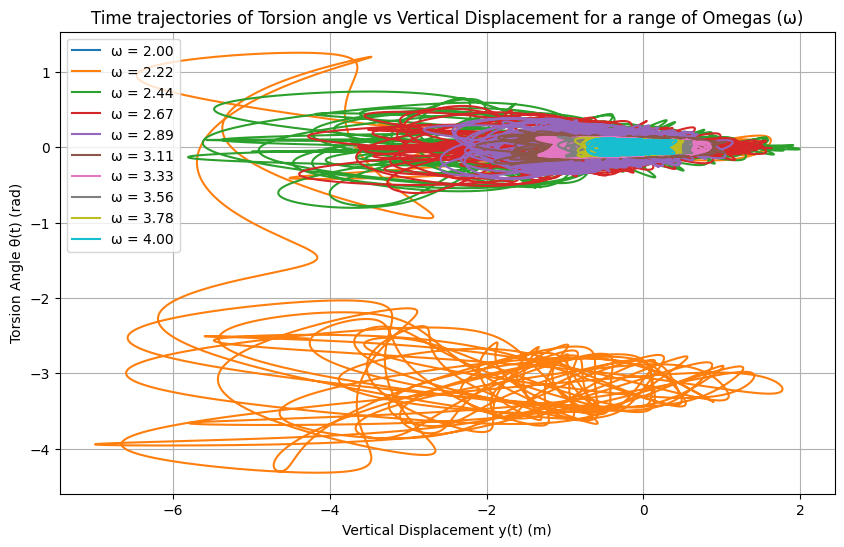

In [23]:
omega_new_range = np.linspace(2,4,10)
wind_amp = 2
results_omegas = []

for omega in omega_new_range:
    times, theta, y = tacoma_wind(dt=0.01, cromer=True, t_start=0, t_end=100, y_0=0.1,
                                  z_0=0, theta_0=0.1, gamma_0=0, d=0.01, l=6, K=10000, M=2500, 
                                  a=1, wind_amp=wind_amp, omega=omega)
    
    results_omegas.append((omega, theta, y))

#Plot Time Trajectories
plt.figure(figsize=(10,6))
for omega, theta, y in results_omegas:
    plt.plot(y, theta, label="ω = {0:.2f}".format(omega))
plt.xlabel("Vertical Displacement y(t) (m)")
plt.ylabel("Torsion Angle θ(t) (rad)")
plt.title("Time trajectories of Torsion angle vs Vertical Displacement for a range of Omegas (ω)")
plt.grid(True)
plt.legend()
plt.show()


At first this graph seems convoluted and hard to understand, however the concept is easily
understood by looking at the frequency values. From we can see from ω = 2.22 until ω = 2.67,
the torsion angle and vertcal displacement observe the greatest shift from the origin. Higher
values of ω exhibit more controlled and constrained oscillations, showing the stability at these
frequencies.

### Open Questions and Discussion

The algorithms defined in this mini project only models a small section of the bridge. If we
wanted to extend the model to the whole bridge, we would model it as a system of coupled
oscillators. Each section would have independent equations of motion - due to different masses,
cables etc. This model would be a lot more complicated, and potentially account for varying
wind force on different sections of the bridge. This could further explain the collapse of the
bridge, as often in physics when there is a system of oscillations it can result in chaotic motion
easily, for example in the double pendulum model.

Another example that exhibits similar resonant behaviour was the Millenium bridge, when it was
opened. This bridge experienced oscillatory movement due to resonance with the walking
frequency of the people walking on top of it [6].

To avoid resonance in systems such as these which is unwanted, damping systems would need
to be applied to the system. Damping absorbs the energy from oscillations, preventing chaotic
and exponential growth of oscillations and preventing resonance. This can be achieved by
adding structural integrity to the model, or even adding things like wind deflectors to a bridge.

### Conclusion

In this report we tackled two challenging problems: Tacoma bridge simulation and TSP. This was
achieved through innovative numerical methods to solve solutions for each problem.

In the TSP project, simulated annealing clearly illustrated its use by finding a very accurate
answer to the shortest path between all 30 cities. Whilst this algorithm clearly works better for
smaller sets of data, such as 8 cities, it can still be highly accurate for a larger data set as long as
a suitable number of iterations is used in the model. Downsides of this model were also seen, as
for larger data sets the run-time can be too long for practical use to obtain an accurate solution.
ALso, the algorithm is hard to define as it depends on a lot of parameters, such as the decay
parameter alpha, that changes the results of the algorithm.

For the Tacoma model, it provides a clear insight on which numerical method is suitable for
second order differential equations, which come up all the time in physics. The Cromer-method
is clearly the preferred method, providing a stable and accurate model of the system. Taylor's
method is too unstable, struggling when the intial conditions are not zero, making it unreliable
for a complex simulation such as this one. The integration of wind force into the model gave an
insight to why the bridge collapsed back in 1940. The frequency of the wind matched the natural
frequency of the bridge, and through the various plots we could see the effect this had on the
vertical displacement and the torsion angle as time progressed. At high values of ω, greater than
3, the system clearly shows stable and insignificant oscillations. Whilst results varied slightly,
the key finding was that when ω was between 2.2 and 2.7, the system was unstable and clearly
this was what led to the faliure of the bridge.

Together, these models show how adressing challenging problems requires a lot of work to do -
tweaking parameters to obtain optimal results and refining iterations to obtain reliable solutions
are vital steps to solve complex problems in physics.


### References

[1] : ScienceDirect (2019): https://www.sciencedirect.com/topics/computer-science/travelingsalesman-problem#:~:text=The%20Traveling%20Salesman%20Problem%20(TSP)%20is
%20a%20well%2Dstudied,since%20the%201920s%20%5B37%5 

[2] : Peter Harrington (2019) https://www.peterharrington.co.uk/der-handlungsreisende-wieer-sein-soll-165666.html

[3] : Baeldung (2021) https://www.baeldung.com/cs/simulated-annealing

[4] Washington State Department of Transportation (2020)
https://wsdot.wa.gov/tnbhistory/bridges-failure.htm

[6] University of Bristol (2021) https://www.bristol.ac.uk/news/2021/december/millenniumbridge-wobble.html